# Variable Production Rate RTD Analysis

## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, cumulative_trapezoid

## 1) Read data

In [2]:
rates = pd.read_csv('../data/injection_production_history.csv').dropna().copy()
obs = pd.read_csv('../data/data.csv')

t_rate_min = rates['Time, min'].to_numpy(dtype=float)
q_bpm = rates['Production Rate, bpm'].to_numpy(dtype=float)
q_bph = q_bpm * 60.0

t_hr = obs['Time_hr'].to_numpy(dtype=float)
c_mgL = obs['C_corr_mgL'].to_numpy(dtype=float)
t_min = t_hr * 60.0

# Interpolate variable production rate onto observation times (in hr basis)
q_obs_bph = np.interp(
    t_min,
    t_rate_min,
    q_bph,
    left=q_bph[0],
    right=q_bph[-1],
)

# RTD in 1/hr
rtd_hr = c_mgL * q_obs_bph * 42.0 * 3.78 / 1e6

## 2) Calculations

In [3]:
rf, _ = quad(
    lambda t: np.interp(t, t_hr, rtd_hr),
    t_hr[0],
    t_hr[-1],
)

v_rtd = rtd_hr / q_obs_bph
v_cum = cumulative_trapezoid(q_obs_bph, t_hr, initial=0.0)
v_mode = v_cum[np.argmax(v_rtd)]

tau_mean, _ = quad(
    lambda t: np.interp(t, t_hr, rtd_hr * t_hr),
    t_hr[0],
    t_hr[-1],
)
tau_mean = tau_mean / rf

var_rtd, _ = quad(
    lambda t: np.interp(t, t_hr, rtd_hr * (t_hr - tau_mean) ** 2),
    t_hr[0],
    t_hr[-1],
)
var_rtd = var_rtd / rf

pv, _ = quad(
    lambda t: np.interp(t, t_hr, rtd_hr * v_cum),
    t_hr[0],
    t_hr[-1],
)
pv_bbl = pv * rf

/tmp/ipykernel_6459/374204723.py:1: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  rf, _ = quad(
/tmp/ipykernel_6459/374204723.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be use

## 3) Display results

,Metric,Value
0,Recovery Factor (-),0.667389
1,Modal Volume (bbl),4390.299882
2,Mean Residence Time (hr),32.390144
3,RTD Variance (hr^2),737.511684
4,Pore Volume (bbl),6317.870420


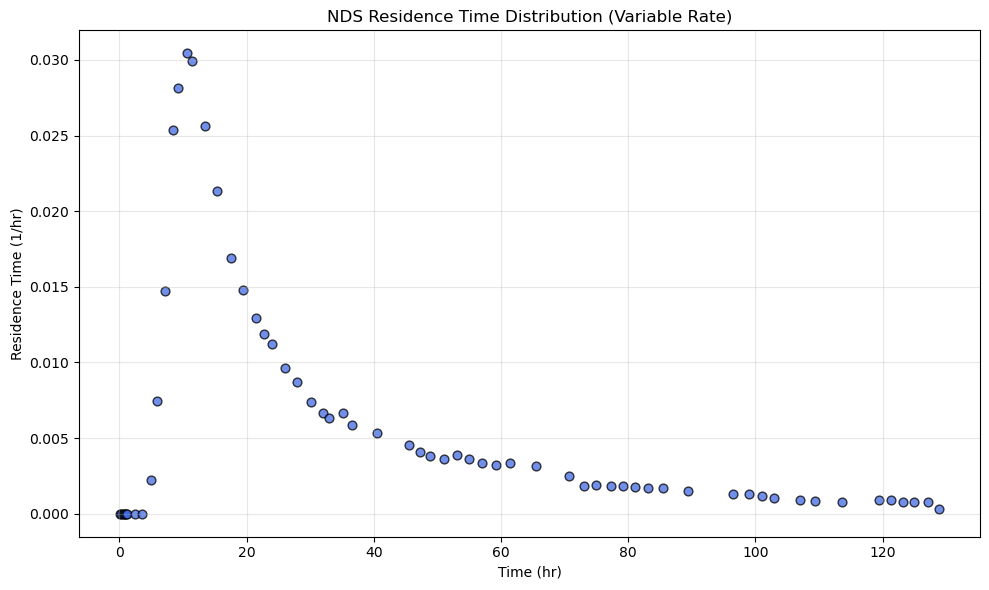

In [4]:
results = pd.DataFrame(
    {
        'Metric': [
            'Recovery Factor (-)',
            'Modal Volume (bbl)',
            'Mean Residence Time (hr)',
            'RTD Variance (hr^2)',
            'Pore Volume (bbl)',
        ],
        'Value': [
            rf,
            v_mode,
            tau_mean,
            var_rtd,
            pv_bbl,
        ],
    }
)

display(results)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.scatter(
    t_hr,
    rtd_hr,
    color='royalblue',
    edgecolor='black',
    alpha=0.75,
    s=40,
)
ax.set_title('NDS Residence Time Distribution (Variable Rate)')
ax.set_xlabel('Time (hr)')
ax.set_ylabel('Residence Time (1/hr)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()